# Transformers: Text generation

The objective of this assignment was to create a transformer capable of generating text from the ground up and investigate how different hyperparameters affect the generated text. Especially if simpler models can be trained faster and still produce decent results, and how the temperature parameter affects the generated text.

The model was trained on Shakespeare's Romeo and Juliet, which contains approximately 140 000 characters. This dataset was chosen because the Shakespeare's writing style is quite unique and recognizable, which makes it easier to evaluate the quality of the generated text. Additionally, the dataset is relatively small compared to modern large language models, which allows for training a transformer model within a reasonable time frame on limited computational resources.

The base for this model was the "LLM_Keras_Kalevala_pieni.ipynb" notebook provided by the teacher.

## Data loading and preprocessing

In [17]:
import os
os.environ['KERAS_BACKEND'] = 'tensorflow'

import numpy as np
import keras
import sentencepiece as spm

The text data is loaded and the first 200 characters are printed to verify that the data is read correctly. The text is then saved to a temporary file, which is used to train the SentencePiece tokenizer.

In [4]:
with open('./shakespeare.txt', 'r', encoding='utf-8-sig') as file:
    text = file.read()

print(f"Text length: {len(text)} characters")
print(f"First 100 characters: {text[:200]}")

Text length: 139738 characters
First 100 characters: Enter Sampson and Gregory armed with swords and bucklers.

SAMPSON.
Gregory, on my word, we’ll not carry coals.

GREGORY.
No, for then we should be colliers.

SAMPSON.
I mean, if we be in choler, we’l


After verifying the text, the SentencePiece tokenizer is trained on the data. The vocabulary size is set to 10,000 and the model type is set to BPE (Byte Pair Encoding). After training, the tokenizer is loaded and a test string is tokenized to demonstrate that the tokenizer works correctly.

In [5]:
temp_file = 'shakespeare_temp.txt'
with open(temp_file, 'w', encoding='utf-8') as f:
    f.write(text)

vocab_size = 10000
model_prefix = 'shakespeare_sp'

spm.SentencePieceTrainer.train(
    input=temp_file,
    model_prefix=model_prefix,
    vocab_size=vocab_size,
    character_coverage=1.0,
    model_type='bpe',
    user_defined_symbols=['<PAD>', '<UNK>']
)

sp = spm.SentencePieceProcessor()
sp.load(f"{model_prefix}.model")

test_text = "O Romeo, Romeo, wherefore art thou Romeo?"
tokens = sp.encode_as_pieces(test_text)
print(f"Tokenized example: {tokens}")
print(f"Vocabulary size: {sp.get_piece_size()}")

Tokenized example: ['▁O', '▁Romeo', ',', '▁Romeo', ',', '▁wherefore', '▁art', '▁thou', '▁Romeo', '?']
Vocabulary size: 10000


Next, the text is tokenized into sequences of a specified length (64 in this case). Each sequence consists of input tokens and target tokens, where the target tokens are the input tokens shifted by one position. The data is then split into training and validation sets.

In [24]:
seq_length = 64
pieces = sp.encode_as_ids(text)
print(f"Total tokens: {len(pieces)}")

sequences = []
for i in range(0, len(pieces) - seq_length):
    sequences.append(pieces[i:i+seq_length+1])

sequences = np.array(sequences)
inputs = sequences[:, :-1]
targets = sequences[:, 1:]

print(f"Number of sequences: {len(sequences)}")
print(f"Input shape: {inputs.shape}")
print(f"Target shape: {targets.shape}")

indices = np.arange(len(sequences))
np.random.shuffle(indices)

train_size = int(0.8 * len(sequences))
train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_inputs, train_targets = inputs[train_indices], targets[train_indices]
val_inputs, val_targets = inputs[val_indices], targets[val_indices]

Total tokens: 33678
Number of sequences: 33614
Input shape: (33614, 64)
Target shape: (33614, 64)


## Larger transformer model

The transformer model is defined using Keras. The model consists of an embedding layer, positional encoding, multiple transformer blocks (each containing multi-head attention and feed-forward layers), and a final dense layer that outputs the logits for each token in the vocabulary. The model is compiled with the Adam optimizer and sparse categorical cross-entropy loss.

In [8]:
def get_positional_encoding(max_len, d_model):
    positions = np.arange(max_len)[:, np.newaxis]
    angles = np.arange(d_model)[np.newaxis, :] / d_model
    angles = 1 / (10000**angles)

    pos_encoding = positions * angles
    pos_encoding[:, 0::2] = np.sin(pos_encoding[:, 0::2])
    pos_encoding[:, 1::2] = np.cos(pos_encoding[:, 1::2])

    return pos_encoding

embed_dim = 192
num_heads = 4
ff_dim = 384
num_layers = 2

inputs = keras.Input(shape=(seq_length,))
embedding_layer = keras.layers.Embedding(sp.get_piece_size(), embed_dim)(inputs)

pos_encoding = get_positional_encoding(seq_length, embed_dim)
x = embedding_layer + pos_encoding

for _ in range(num_layers):
    attention_output = keras.layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=embed_dim // num_heads,
        dropout=0.1
    )(x, x, use_causal_mask=True)

    x = keras.layers.LayerNormalization(epsilon=1e-6)(x + attention_output)

    ffn = keras.Sequential([
        keras.layers.Dense(ff_dim, activation="relu"),
        keras.layers.Dense(embed_dim),
        keras.layers.Dropout(0.1)
    ])
    ffn_output = ffn(x)

    x = keras.layers.LayerNormalization(epsilon=1e-6)(x + ffn_output)

outputs = keras.layers.Dense(sp.get_piece_size())(x)

model = keras.Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 64, 192)   │  1,920,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 192)   │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 192)   │    148,224 │ add[0][0],        │
│ (MultiHeadAttentio… │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 64, 192)   │          0 │ add[0][0],        │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 64, 192)   │        384 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 64, 192)   │    148,032 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 64, 192)   │          0 │ layer_normalizat… │
│                     │                   │            │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 192)   │        384 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 192)   │    148,224 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 64, 192)   │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 192)   │        384 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 64, 192)   │    148,032 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 64, 192)   │          0 │ layer_normalizat… │
│                     │                   │            │ sequential_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 192)   │        384 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64, 10000) │  1,930,000 │ layer_normalizat… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,444,048 (16.95 MB)

 Trainable params: 4,444,048 (16.95 MB)

 Non-trainable params: 0 (0.00 B)

The model is trained for a maximum of 100 epochs with a batch size of 128. Early stopping is used to prevent overfitting, and the learning rate is reduced if the validation loss does not improve.

Because of the limited processing power available, even this relatively small model took a long time to train. Approximately 5 hours.

In [9]:
batch_size = 128
epochs = 100

history = model.fit(
    train_inputs, train_targets,
    validation_data=(val_inputs, val_targets),
    batch_size=batch_size,
    epochs=epochs,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=1),
        keras.callbacks.ModelCheckpoint('shakespeare_best_model.keras', save_best_only=True)
    ]
)

Epoch 1/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 183s 826ms/step - accuracy: 0.0654 - loss: 7.9313 - val_accuracy: 0.0694 - val_loss: 6.8785 - learning_rate: 5.0000e-05
Epoch 2/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 170s 803ms/step - accuracy: 0.0720 - loss: 6.4720 - val_accuracy: 0.0855 - val_loss: 6.2466 - learning_rate: 5.0000e-05
Epoch 3/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 171s 811ms/step - accuracy: 0.0798 - loss: 6.1983 - val_accuracy: 0.0782 - val_loss: 6.1782 - learning_rate: 5.0000e-05
Epoch 4/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 168s 797ms/step - accuracy: 0.0895 - loss: 6.1571 - val_accuracy: 0.1064 - val_loss: 6.1164 - learning_rate: 5.0000e-05
Epoch 5/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 170s 807ms/step - accuracy: 0.1266 - loss: 5.9112 - val_accuracy: 0.1403 - val_loss: 5.6441 - learning_rate: 5.0000e-05
Epoch 6/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 168s 798ms/step - accuracy: 0.1537 - loss: 5.4432 - val_accuracy: 0.1661 - val_loss: 5.2210 - learning_rate: 5.0000e-05
Epoch 7/100
211/211 ━━━━━━━━━━━━━━

After training, the loss and accuracy curves for both training and validation sets are plotted to visualize the model's performance over epochs. As can be seen from the plots, the model converged well without any signs of overfitting and reached a validation accuracy of around 0.96 %, which is quite good considering the relatively small model and limited training time.

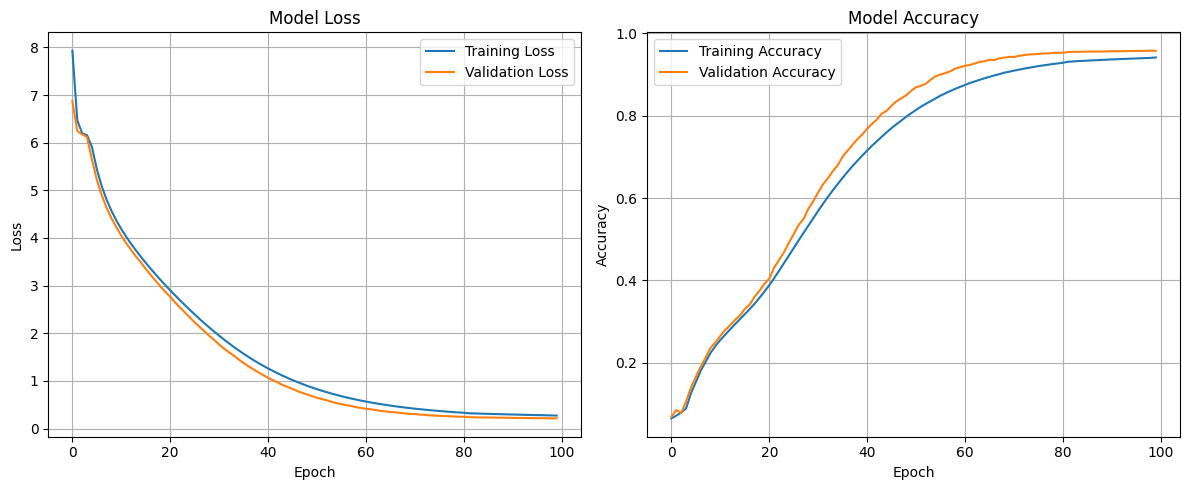

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid()
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

In order to generate text, a function is defined that takes a prompt and generates a specified number of tokens. The function encodes the prompt using the SentencePiece tokenizer, pads or truncates it to the required sequence length, and then iteratively predicts the next token until the desired number of tokens is generated. The generated token IDs are then decoded back into text using the tokenizer.

## Text generation with the larger model

In [12]:
def generate_text(model, sp, prompt, num_tokens=100, temperature=1.0):
    input_ids = sp.encode_as_ids(prompt)

    if len(input_ids) < seq_length:
        padding_length = seq_length - len(input_ids)
        input_ids = [0] * padding_length + input_ids
    else:
        padding_length = 0
        input_ids = input_ids[-seq_length:]

    generated_ids = list(input_ids[padding_length:])

    for _ in range(num_tokens):
        x = np.array([input_ids])
        predictions = model.predict(x, verbose=0)[0]
        logits = predictions[-1]
        logits = logits / temperature
        exp_logits = np.exp(logits - np.max(logits))
        probs = exp_logits / np.sum(exp_logits)
        next_token = np.random.choice(len(probs), p=probs)
        generated_ids.append(next_token)
        input_ids = input_ids[1:] + [next_token]

    generated_text = sp.decode(generated_ids)

    return generated_text

The text generation function is tested with different prompts and temperature settings. The temperature parameter controls the randomness of the generated text, with higher values producing more diverse outputs and lower values producing more deterministic outputs. The generated text is printed for each prompt and temperature setting to observe the differences in the output.

In [25]:
prompts = [
    "Romeo",
    "Juliet",
    "Where are",
    "Poison"
]

for prompt in prompts:
    print(f"\nPrompt: {prompt}")
    generated = generate_text(model, sp, prompt, num_tokens=100, temperature=1.0)
    print(generated)


Prompt: Romeo
Romeo, And stay to the County’s Page that rais’d the watch? Sirrah, what made your master in this place? PAGE. He came, who began this bloody fray? BENVOLIO. Tybalt, here slain, whom Romeo’s hand did slay; Romeo, that spoke him fair, bid him bethink How nice the quarrel was, and urg’d withal Your high displeasure. All this uttered With gentle breath, calm look, knees humbly bow’d Could not take truce with the unruly spleen

Prompt: Juliet
Juliet. ’Tis but she, the best friend I made. MERCUTIO. O, a certain text. Come you to make confession to make confession to this father? JULIET. To answer that, I should confess to you. PARIS. Do had then, with thee death, [_Exeunt._] SCENE IV. A Room in Capulet’s House. Enter Capulet, Lady Capulet, Nurse. LADY CAPULET. What, are you busy, ho? Need you my help? JULIET. No, madam; we have

Prompt: Where are
Where are a man, And she’s dead, she’s dead, that would have slain my husband. All this is comfort; wherefore weep I then? Some wor

In [26]:
prompts = [
    "Romeo",
    "Juliet",
    "Where are",
    "Poison"
]

for prompt in prompts:
    print(f"\nPrompt: {prompt}")
    generated = generate_text(model, sp, prompt, num_tokens=100, temperature=0.5)
    print(generated)


Prompt: Romeo
Romeo, And go, But now, wife, being one in black fate on mo days doth depend; This but begins the woe others must end. Re-enter Tybalt. BENVOLIO. Here comes the furious Tybalt back again. ROMEO. Again in triumph, and Mercutio slain? Away to heaven respective lenity, And fire-ey’d fury be my conduct now! Now, Tybalt, take the ‘villain’ back again That late thou gav’st me, for Mercutio’s soul Is but a little

Prompt: Juliet
Juliet, And yet no more I shall use to jest. Thursday is near; lay hand on heart, advise. And you be mine, I’ll give you to my friend; And you be a poison, which the Friar Subtly hath minister’d to have me dead, Lest in this marriage he should be dishonour’d, Because he married me before to Romeo? I fear it is. And yet methinks it should not, For he hath still been tried a holy man. How if, when

Prompt: Where are
Where are a man, And she looks as pale as any clout in the versal world. Doth not rosemary and Romeo begin both with a letter? ROMEO. Ay, Nur

In [27]:
prompts = [
    "Romeo",
    "Juliet",
    "Where are",
    "Poison"
]

for prompt in prompts:
    print(f"\nPrompt: {prompt}")
    generated = generate_text(model, sp, prompt, num_tokens=100, temperature=1.5)
    print(generated)


Prompt: Romeo
Romeo, And yet a joyful woman? JULIET. What wilt thou mayst think my daylight, But I do more, it shall I am much for this, ’tis not so deep temper it. Ah, maidenhead, at twelve philosophy. What, Displant a town, still my dear love attempt: Therefore thy kinsmen are no stop to me. JULIET. If they do see that we held him were says he of infection. noise’s the alligator stuff’d, and other skins Of ill-shapedTwixt

Prompt: Juliet
Juliet, And yet so much in twenty years; for it is enough, if it festering in? Came I thought us so older when they had allied, Stuff’d, as they knew not were in that thou sallow cheeks for Rosaline! How stands breast. Enter Citizens. FIRST CITIZEN. For sworn that he’t if they be, indeed; there with his fearful endure him That name, which is much abus’d with tears. JULIET. How is arm that honourable parts, Proportion’d as

Prompt: Where are
Where are a man, And stay the nurse this night sit up with you, For you sad hours seem long. Was that my weddi

Overall, the generated text resembles Shakespeare's style, though it contains some nonsensical phrases. The model captures the general structure and vocabulary of Shakespeare's writing, but due to the limited training time and relatively small model size, it struggles to produce coherent sentences consistently. The temperature setting also has a noticeable impact on the diversity of the generated text, with higher temperatures producing more creative but less coherent outputs.

It is possible that Shakespeare's writing style, which includes a lot of old English and unique vocabulary, may have made it more challenging for the model to learn effectively, especially with a smaller dataset and limited training time. A larger model or more training data might yield better results, but it would also require significantly more computational resources and time to train.

## Smaller transformer model

To investigate if a smaller model can be trained faster while still producing decent results, the model architecture is modified to have fewer parameters. The embedding dimension, number of heads, feed-forward dimension, and number of layers are all reduced. The same training process is then repeated with the smaller model to compare the results.

In [14]:
seq_length = 32
pieces = sp.encode_as_ids(text)
print(f"Total tokens: {len(pieces)}")

sequences = []
for i in range(0, len(pieces) - seq_length):
    sequences.append(pieces[i:i+seq_length+1])

sequences = np.array(sequences)
inputs = sequences[:, :-1]
targets = sequences[:, 1:]

print(f"Number of sequences: {len(sequences)}")
print(f"Input shape: {inputs.shape}")
print(f"Target shape: {targets.shape}")

indices = np.arange(len(sequences))
np.random.shuffle(indices)

train_size = int(0.8 * len(sequences))
train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_inputs, train_targets = inputs[train_indices], targets[train_indices]
val_inputs, val_targets = inputs[val_indices], targets[val_indices]

Total tokens: 33678
Number of sequences: 33646
Input shape: (33646, 32)
Target shape: (33646, 32)


As can be seen the model architecture is significantly smaller than the previous one with only 1,3 million parameters compared to 4,5 million. This smaller model took approximately 2 hours to train, which is a significant reduction in training time compared to the larger model.

In [15]:
embed_dim = 64
num_heads = 2
ff_dim = 384
num_layers = 1

inputs = keras.Input(shape=(seq_length,))
embedding_layer = keras.layers.Embedding(sp.get_piece_size(), embed_dim)(inputs)

pos_encoding = get_positional_encoding(seq_length, embed_dim)
x = embedding_layer + pos_encoding

for _ in range(num_layers):
    attention_output = keras.layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=embed_dim // num_heads,
        dropout=0.1
    )(x, x, use_causal_mask=True)

    x = keras.layers.LayerNormalization(epsilon=1e-6)(x + attention_output)

    ffn = keras.Sequential([
        keras.layers.Dense(ff_dim, activation="relu"),
        keras.layers.Dense(embed_dim),
        keras.layers.Dropout(0.1)
    ])
    ffn_output = ffn(x)

    x = keras.layers.LayerNormalization(epsilon=1e-6)(x + ffn_output)

outputs = keras.layers.Dense(sp.get_piece_size())(x)

model = keras.Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

model.summary()


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 32)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 32, 64)    │    640,000 │ input_layer_3[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 32, 64)    │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 32, 64)    │     16,640 │ add_5[0][0],      │
│ (MultiHeadAttentio… │                   │            │ add_5[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 32, 64)    │          0 │ add_5[0][0],      │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 32, 64)    │        128 │ add_6[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_2        │ (None, 32, 64)    │     49,600 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 32, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ sequential_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 32, 64)    │        128 │ add_7[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 32, 10000) │    650,000 │ layer_normalizat… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,356,496 (5.17 MB)

 Trainable params: 1,356,496 (5.17 MB)

 Non-trainable params: 0 (0.00 B)

The model is trained using the same training loop as before, with early stopping and learning rate reduction callbacks.

In [16]:
batch_size = 128
epochs = 100

history = model.fit(
    train_inputs, train_targets,
    validation_data=(val_inputs, val_targets),
    batch_size=batch_size,
    epochs=epochs,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=1),
        keras.callbacks.ModelCheckpoint('shakespeare_fast_model.keras', save_best_only=True)
    ]
)

Epoch 1/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 56s 243ms/step - accuracy: 0.0489 - loss: 8.7546 - val_accuracy: 0.0703 - val_loss: 8.2416 - learning_rate: 5.0000e-05
Epoch 2/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 52s 246ms/step - accuracy: 0.0696 - loss: 7.8405 - val_accuracy: 0.0703 - val_loss: 7.4414 - learning_rate: 5.0000e-05
Epoch 3/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 56s 264ms/step - accuracy: 0.0704 - loss: 7.1551 - val_accuracy: 0.0703 - val_loss: 6.8896 - learning_rate: 5.0000e-05
Epoch 4/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 52s 247ms/step - accuracy: 0.0705 - loss: 6.7001 - val_accuracy: 0.0703 - val_loss: 6.5427 - learning_rate: 5.0000e-05
Epoch 5/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 55s 260ms/step - accuracy: 0.0705 - loss: 6.4277 - val_accuracy: 0.0703 - val_loss: 6.3407 - learning_rate: 5.0000e-05
Epoch 6/100
211/211 ━━━━━━━━━━━━━━━━━━━━ 56s 264ms/step - accuracy: 0.0709 - loss: 6.2711 - val_accuracy: 0.0732 - val_loss: 6.2216 - learning_rate: 5.0000e-05
Epoch 7/100
211/211 ━━━━━━━━━━━━━━━━━━━━

As with the larger model, the loss and accuracy curves for both training and validation sets are plotted to visualize the model's performance over epochs. The smaller model converged about as fast as the larger model, but did not reach as high validation accuracy, peaking only at around 0.58 %. The training could have been continued for more epochs, but since the idea was to see if a smaller model can be trained faster while still producing decent results, training the model longer would have defeated the purpose of this experiment. The smaller model is significantly faster to train, but it does not perform as well as the larger model in terms of accuracy.

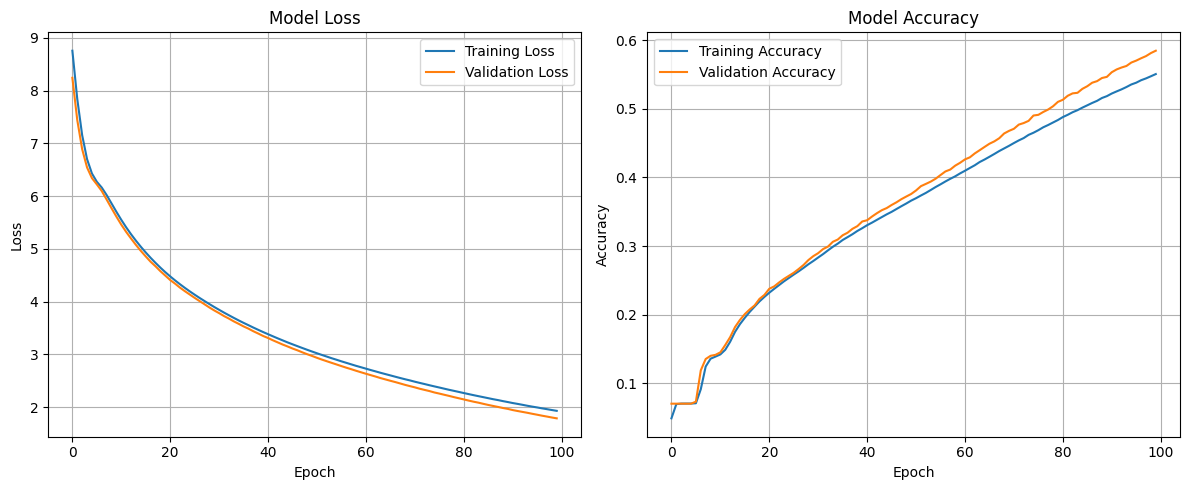

In [20]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid()
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

Finally, the text generation function is tested again with the smaller model using the same prompts and the temperature setting of 1.0. The generated text is printed for each prompt to observe the differences in the output compared to the larger model. The smaller model produces less coherent and more nonsensical text compared to the larger model, though the difference is not as significant as the difference in validation accuracy might suggest. The smaller model still captures some of the style and vocabulary of Shakespeare's writing, but it struggles more to produce coherent sentences occasionally.

In [21]:
prompts = [
    "Romeo",
    "Juliet",
    "Where are",
    "Poison"
]

for prompt in prompts:
    print(f"\nPrompt: {prompt}")
    generated = generate_text(model, sp, prompt, num_tokens=100, temperature=1.0)
    print(generated)


Prompt: Romeo
Romeo that is my thumb at me, sir; a thousand times the Capulets lie. [_Noise within._] FRIAR LAWRENCE. I do not fall into so most courteous, or both, and a torch, we shall share the glory, That in gold clasps locks in the golden story; Unwieldy, clos’d in proof of hope, and odd days. [_Sings._] An old hare hoar, To call the public haunt of men. thanks. ROMEO. [_Retires._] FRIAR LAWRENCE. With nimble-pinion’

Prompt: Juliet
Juliet’s law of our masters and us their true descent, It were he was the house Where which is disgrace to them if ought in this Miscarried by my light I, let my old daughter’s Chamber. Enter Romeo. ROMEO. Madam. What, because musicians sound for cracking nuts, no excuse his father a hast we not fourteen years Be not then a fair best robes, bent of love be merry look. What say, good counsel, and I cannot sit up, They’ll have none

Prompt: Where are
Where are you have an untimely borrow Cupid’s nose, And then dreams kiss consume. The time and his lette

## Discussion

In conclusion, the larger transformer model produced a little bit more coherent text and achieved alot higher validation accuracy compared to the smaller model. Though the difference in training time was significant, which in this case puts in the question if the improvement in text quality is worth the extra training time.

It is clear that significant computational resources are required to train a transformer model that can generate high-quality text, which makes the pretrained large language models like GPT-5 and Gemini so valuable. Since the models are already trained, it is computationally efficient to use them for text generation tasks.

The temperature parameter was found to have a impact on the generated text. Higher temperatures produced more diverse and creative outputs, but they were also less coherent and more likely to contain nonsensical phrases. Lower temperatures produced more deterministic outputs that were more coherent but less diverse.